<a href="https://colab.research.google.com/github/malsha890/NLP-Based-Singlish-Need-Classification-System-/blob/main/nlp%20service/Extensions_epoch_sweep_MuRIL_transliteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://malsha890:@github.com/malsha890/NLP-Based-Singlish-Need-Classification-System-.git
%cd NLP-Based-Singlish-Need-Classification-System-/nlp\ service
!pip install transformers peft
!git config --global user.email "malshagonaduwa723@gmail.com"
!git config --global user.name "malsha890"

fatal: destination path 'NLP-Based-Singlish-Need-Classification-System-' already exists and is not an empty directory.
/content/NLP-Based-Singlish-Need-Classification-System-/nlp service


In [2]:
import pandas as pd
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from hybrid_tokenizer import hybrid_encode, baseline_encode
from model import SinglishNeedClassifier, get_aux_features

CATEGORIES = ["medical aid", "shelter", "food/water", "rescue/missing", "other"]
LABEL2ID = {c: i for i, c in enumerate(CATEGORIES)}

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

class NeedDataset(Dataset):
    def __init__(self, dataframe, encode_fn):
        self.df = dataframe.reset_index(drop=True)
        self.encode_fn = encode_fn
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        input_ids, attention_mask = self.encode_fn(row["text"])
        aux = get_aux_features(row["text"])
        return {
            "input_ids": torch.tensor(input_ids),
            "attention_mask": torch.tensor(attention_mask),
            "aux_features": torch.tensor(aux, dtype=torch.float),
            "label": torch.tensor(LABEL2ID[row["category"]]),
        }

train_full = pd.read_csv("../data/train_augmented.csv")
train_final, val_final = train_test_split(train_full, test_size=0.15, stratify=train_full["category"], random_state=42)
test_clean = pd.read_csv("../data/test_clean.csv")
test_robust = pd.read_csv("../data/test_robustness.csv")

classes_ordered = CATEGORIES
weights = compute_class_weight("balanced", classes=np.array(classes_ordered), y=train_final["category"])
class_weights_tensor = torch.tensor(weights, dtype=torch.float).to("cuda")

def evaluate(model, dataframe, encode_fn):
    dataset = NeedDataset(dataframe, encode_fn)
    loader = DataLoader(dataset, batch_size=16)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            logits = model(batch["input_ids"].to("cuda"), batch["attention_mask"].to("cuda"), batch["aux_features"].to("cuda"))
            preds.extend(logits.argmax(dim=1).cpu().tolist())
            labels.extend(batch["label"].tolist())
    return f1_score(labels, preds, average="macro")

print("Setup complete.")

Setup complete.


In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
def train_one_run_epoch_sweep(encode_fn, seed, max_epochs=24, eval_every=1):
    set_seed(seed)
    model = SinglishNeedClassifier().to("cuda")
    optimizer = AdamW(model.parameters(), lr=2e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    train_loader = DataLoader(NeedDataset(train_final, encode_fn), batch_size=16, shuffle=True)

    epoch_results = []
    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(batch["input_ids"].to("cuda"),
                            batch["attention_mask"].to("cuda"),
                            batch["aux_features"].to("cuda"))
            loss = criterion(logits, batch["label"].to("cuda"))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)

        if epoch % eval_every == 0 or epoch == max_epochs:
            val_f1 = evaluate(model, val_final, encode_fn)
            test_f1 = evaluate(model, test_clean, encode_fn)
            robust_f1 = evaluate(model, test_robust, encode_fn)
            epoch_results.append({
                "epoch": epoch, "train_loss": avg_loss,
                "val_f1": val_f1, "test_f1": test_f1, "robustness_f1": robust_f1,
            })
            print(f"  epoch {epoch}: loss={avg_loss:.4f}, val={val_f1:.3f}, test={test_f1:.3f}, robust={robust_f1:.3f}")

    return epoch_results

In [8]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 46.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [5]:
sweep_rows = []
for name, encode_fn in [("baseline", baseline_encode), ("hybrid", hybrid_encode)]:
    for seed in [13, 42, 77]:
        print(f"Sweeping {name}, seed {seed}...")
        results = train_one_run_epoch_sweep(encode_fn, seed, max_epochs=24)
        for r in results:
            r["tokenizer"] = name
            r["seed"] = seed
            sweep_rows.append(r)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv("../data/epoch_sweep_results.csv", index=False)

Sweeping baseline, seed 13...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1: loss=1.6274, val=0.067, test=0.067, robust=0.125
  epoch 2: loss=1.6031, val=0.234, test=0.193, robust=0.118
  epoch 3: loss=1.5221, val=0.517, test=0.593, robust=0.487
  epoch 4: loss=1.1802, val=0.732, test=0.723, robust=0.703
  epoch 5: loss=0.8568, val=0.778, test=0.788, robust=0.637
  epoch 6: loss=0.6538, val=0.822, test=0.757, robust=0.650
  epoch 7: loss=0.5342, val=0.867, test=0.813, robust=0.717
  epoch 8: loss=0.4325, val=0.898, test=0.792, robust=0.708
  epoch 9: loss=0.3366, val=0.937, test=0.889, robust=0.719
  epoch 10: loss=0.3430, val=0.936, test=0.887, robust=0.709
  epoch 11: loss=0.2606, val=0.949, test=0.842, robust=0.706
  epoch 12: loss=0.2251, val=0.956, test=0.866, robust=0.747
  epoch 13: loss=0.1896, val=0.968, test=0.834, robust=0.706
  epoch 14: loss=0.1810, val=0.962, test=0.887, robust=0.787
  epoch 15: loss=0.1521, val=0.968, test=0.841, robust=0.691
  epoch 16: loss=0.1491, val=0.968, test=0.821, robust=0.705
  epoch 17: loss=0.1355, val=0.96

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1: loss=1.6239, val=0.068, test=0.086, robust=0.047
  epoch 2: loss=1.6029, val=0.240, test=0.246, robust=0.237
  epoch 3: loss=1.5538, val=0.544, test=0.542, robust=0.518
  epoch 4: loss=1.2631, val=0.669, test=0.620, robust=0.663
  epoch 5: loss=0.9028, val=0.755, test=0.615, robust=0.635
  epoch 6: loss=0.7027, val=0.861, test=0.711, robust=0.666
  epoch 7: loss=0.5149, val=0.892, test=0.754, robust=0.760
  epoch 8: loss=0.4342, val=0.924, test=0.743, robust=0.746
  epoch 9: loss=0.3309, val=0.912, test=0.792, robust=0.723
  epoch 10: loss=0.2810, val=0.943, test=0.801, robust=0.727
  epoch 11: loss=0.2699, val=0.931, test=0.713, robust=0.604
  epoch 12: loss=0.2611, val=0.968, test=0.781, robust=0.685
  epoch 13: loss=0.2005, val=0.949, test=0.819, robust=0.746
  epoch 14: loss=0.2065, val=0.950, test=0.847, robust=0.734
  epoch 15: loss=0.1612, val=0.956, test=0.847, robust=0.733
  epoch 16: loss=0.1485, val=0.962, test=0.820, robust=0.766
  epoch 17: loss=0.1162, val=0.96

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1: loss=1.6185, val=0.067, test=0.084, robust=0.047
  epoch 2: loss=1.6072, val=0.227, test=0.182, robust=0.196
  epoch 3: loss=1.5826, val=0.371, test=0.274, robust=0.299
  epoch 4: loss=1.4651, val=0.654, test=0.580, robust=0.553
  epoch 5: loss=1.0969, val=0.720, test=0.600, robust=0.589
  epoch 6: loss=0.8317, val=0.832, test=0.675, robust=0.638
  epoch 7: loss=0.6121, val=0.876, test=0.732, robust=0.608
  epoch 8: loss=0.4524, val=0.848, test=0.698, robust=0.684
  epoch 9: loss=0.4327, val=0.904, test=0.740, robust=0.634
  epoch 10: loss=0.3212, val=0.925, test=0.794, robust=0.750
  epoch 11: loss=0.2766, val=0.962, test=0.840, robust=0.803
  epoch 12: loss=0.2776, val=0.956, test=0.842, robust=0.721
  epoch 13: loss=0.2178, val=0.944, test=0.737, robust=0.719
  epoch 14: loss=0.2075, val=0.962, test=0.794, robust=0.747
  epoch 15: loss=0.1881, val=0.994, test=0.798, robust=0.720
  epoch 16: loss=0.1731, val=0.981, test=0.839, robust=0.759
  epoch 17: loss=0.1377, val=0.96

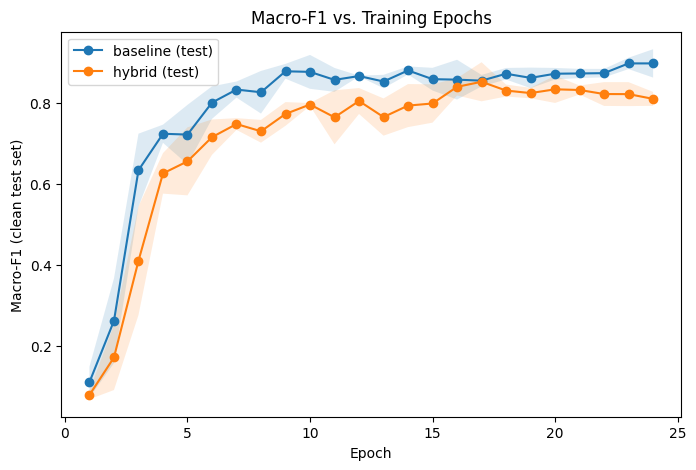

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for name in ["baseline", "hybrid"]:
    subset = sweep_df[sweep_df["tokenizer"] == name]
    grouped = subset.groupby("epoch")["test_f1"].agg(["mean", "std"])
    ax.plot(grouped.index, grouped["mean"], label=f"{name} (test)", marker="o")
    ax.fill_between(grouped.index, grouped["mean"] - grouped["std"], grouped["mean"] + grouped["std"], alpha=0.15)
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro-F1 (clean test set)")
ax.set_title("Macro-F1 vs. Training Epochs")
ax.legend()
plt.savefig("../data/epoch_sweep_plot.png", dpi=200, bbox_inches="tight")

In [7]:
for name in ["baseline", "hybrid"]:
    subset = sweep_df[sweep_df["tokenizer"] == name]
    avg_by_epoch = subset.groupby("epoch")[["val_f1", "test_f1"]].mean()
    best_epoch = avg_by_epoch["val_f1"].idxmax()
    print(f"{name}: best val_f1 = {avg_by_epoch['val_f1'].max():.3f} at epoch {best_epoch}")
    print(f"{name}: val_f1 at epoch 24 = {avg_by_epoch['val_f1'].iloc[-1]:.3f}")
    print()

baseline: best val_f1 = 0.977 at epoch 22
baseline: val_f1 at epoch 24 = 0.975

hybrid: best val_f1 = 0.973 at epoch 15
hybrid: val_f1 at epoch 24 = 0.968



In [8]:
%%writefile muril_tokenizer.py
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")
MAX_LEN = 64

def hybrid_encode_muril(text, oov_threshold=0.4):
    ids = [tokenizer.cls_token_id]
    for word in text.strip().split():
        pieces = tokenizer.tokenize(word)
        fragmentation = len(pieces) / max(len(word), 1)
        if fragmentation > oov_threshold or tokenizer.unk_token in pieces:
            for ch in word:
                ch_ids = tokenizer.convert_tokens_to_ids(tokenizer.tokenize(ch))
                ids.extend(ch_ids if ch_ids else [tokenizer.unk_token_id])
        else:
            ids.extend(tokenizer.convert_tokens_to_ids(pieces))
    ids.append(tokenizer.sep_token_id)
    ids = ids[:MAX_LEN]
    attention_mask = [1] * len(ids)
    pad_len = MAX_LEN - len(ids)
    ids += [tokenizer.pad_token_id] * pad_len
    attention_mask += [0] * pad_len
    return ids, attention_mask

def baseline_encode_muril(text):
    out = tokenizer(text, padding="max_length", truncation=True, max_length=MAX_LEN)
    return out["input_ids"], out["attention_mask"]

Writing muril_tokenizer.py


In [11]:
%%writefile model.py
from transformers import AutoModel
from peft import LoraConfig, get_peft_model
import torch
import torch.nn as nn

NEED_KEYWORDS = ["one", "epa", "please", "ikmanin", "ikmanata", "help",
                  "urgent", "puluwanda", "asaneepa",
                  "kadila", "thuwala", "amarui", "ambulance", "doctor", "beheth", "ospital"]

def get_aux_features(text):
    words = text.lower().split()
    length_feature = min(len(words) / 20, 1.0)
    keyword_hits = sum(1 for w in words if w in NEED_KEYWORDS)
    keyword_feature = min(keyword_hits / 3, 1.0)
    return [length_feature, keyword_feature]

class SinglishNeedClassifier(nn.Module):
    def __init__(self, base_model_name="xlm-roberta-base", num_categories=5, aux_feature_dim=2):
        super().__init__()
        base = AutoModel.from_pretrained(base_model_name)
        lora_config = LoraConfig(
            r=8, lora_alpha=16,
            target_modules=["query", "value"],
            lora_dropout=0.1,
        )
        self.encoder = get_peft_model(base, lora_config)
        hidden = base.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden + aux_feature_dim, 128),
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_categories),
        )

    def forward(self, input_ids, attention_mask, aux_features):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]
        combined = torch.cat([pooled, aux_features], dim=1)
        return self.classifier(combined)

Overwriting model.py


In [12]:
import importlib
import model

importlib.reload(model)

from model import SinglishNeedClassifier

In [13]:
import inspect

print(inspect.signature(SinglishNeedClassifier.__init__))

(self, base_model_name='xlm-roberta-base', num_categories=5, aux_feature_dim=2)


In [14]:
from model import SinglishNeedClassifier
from muril_tokenizer import hybrid_encode_muril, baseline_encode_muril

def train_one_run_muril(encode_fn, seed, epochs=8):
    set_seed(seed)
    model = SinglishNeedClassifier(base_model_name="google/muril-base-cased").to("cuda")
    optimizer = AdamW(model.parameters(), lr=2e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    train_loader = DataLoader(NeedDataset(train_final, encode_fn), batch_size=16, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(batch["input_ids"].to("cuda"), batch["attention_mask"].to("cuda"), batch["aux_features"].to("cuda"))
            loss = criterion(logits, batch["label"].to("cuda"))
            loss.backward()
            optimizer.step()

    test_f1 = evaluate(model, test_clean, encode_fn)
    robust_f1 = evaluate(model, test_robust, encode_fn)
    return test_f1, robust_f1

muril_results = []
for name, encode_fn in [("baseline", baseline_encode_muril), ("hybrid", hybrid_encode_muril)]:
    for seed in [13, 42, 77, 101, 256]:
        print(f"MuRIL {name}, seed {seed}...")
        test_f1, robust_f1 = train_one_run_muril(encode_fn, seed)
        muril_results.append({"backbone": "MuRIL", "tokenizer": name, "seed": seed, "test_f1": test_f1, "robustness_f1": robust_f1})

muril_df = pd.DataFrame(muril_results)
muril_df.to_csv("../data/results_muril.csv", index=False)

MuRIL baseline, seed 13...


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  953MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MuRIL hybrid, seed 256...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
xlmr_df = pd.read_csv("../data/results.csv")
xlmr_df["backbone"] = "XLM-R"
all_results = pd.concat([xlmr_df, muril_df], ignore_index=True)
all_results.to_csv("../data/results_all_backbones.csv", index=False)

print(all_results.groupby(["backbone", "tokenizer"])[["test_f1", "robustness_f1"]].agg(["mean", "std"]))

                     test_f1           robustness_f1          
                        mean       std          mean       std
backbone tokenizer                                            
MuRIL    baseline   0.765732  0.021851      0.636108  0.046827
         hybrid     0.781411  0.048276      0.648567  0.073250
XLM-R    baseline   0.818223  0.033910      0.686359  0.031919
         hybrid     0.798593  0.072962      0.690925  0.055564


In [16]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

translit_tokenizer = AutoTokenizer.from_pretrained("kasunw/sinhala-transliterator")
translit_model = AutoModelForSeq2SeqLM.from_pretrained("kasunw/sinhala-transliterator").to("cuda")

def transliterate(text):
    inputs = translit_tokenizer(text, return_tensors="pt", truncation=True).to("cuda")
    with torch.no_grad():
        output_ids = translit_model.generate(**inputs, max_new_tokens=64)
    return translit_tokenizer.decode(output_ids[0], skip_special_tokens=True)

config.json:   0%|          | 0.00/931 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.8k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 2.42MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/2.01k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.56k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.94GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]

In [17]:
for df, name in [(train_final, "train_final"), (val_final, "val_final"), (test_clean, "test_clean"), (test_robust, "test_robust")]:
    df["text_si"] = df["text"].apply(transliterate)
    df.to_csv(f"../data/{name}_transliterated.csv", index=False)
    print(f"Done: {name}")

[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Done: train_final


[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Done: val_final


[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Done: test_clean


[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Done: test_robust


In [18]:
%%writefile sinhala_tokenizer.py
from transformers import AutoTokenizer

si_tokenizer = AutoTokenizer.from_pretrained("keshan/sinhala-roberta-oscar")
MAX_LEN = 64

def sinhala_encode(text_si):
    out = si_tokenizer(text_si, padding="max_length", truncation=True, max_length=MAX_LEN)
    return out["input_ids"], out["attention_mask"]

Writing sinhala_tokenizer.py


In [20]:
from sklearn.metrics import f1_score
import torch

def evaluate_loader(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:

            input_ids = batch["input_ids"].to("cuda")
            attention_mask = batch["attention_mask"].to("cuda")
            aux_features = batch["aux_features"].to("cuda")
            labels = batch["label"].to("cuda")

            logits = model(
                input_ids,
                attention_mask,
                aux_features
            )

            predictions = torch.argmax(logits, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

In [21]:
from sinhala_tokenizer import sinhala_encode

class NeedDatasetSinhala(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        input_ids, attention_mask = sinhala_encode(row["text_si"])
        aux = get_aux_features(row["text"])  # aux features still computed from original Singlish text
        return {
            "input_ids": torch.tensor(input_ids),
            "attention_mask": torch.tensor(attention_mask),
            "aux_features": torch.tensor(aux, dtype=torch.float),
            "label": torch.tensor(LABEL2ID[row["category"]]),
        }

def train_translit_first(seed, epochs=8):
    set_seed(seed)
    model = SinglishNeedClassifier(base_model_name="keshan/sinhala-roberta-oscar").to("cuda")
    optimizer = AdamW(model.parameters(), lr=2e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    train_loader = DataLoader(NeedDatasetSinhala(train_final), batch_size=16, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(batch["input_ids"].to("cuda"), batch["attention_mask"].to("cuda"), batch["aux_features"].to("cuda"))
            loss = criterion(logits, batch["label"].to("cuda"))
            loss.backward()
            optimizer.step()

    test_loader = DataLoader(NeedDatasetSinhala(test_clean), batch_size=16)
    robust_loader = DataLoader(NeedDatasetSinhala(test_robust), batch_size=16)
    test_f1 = evaluate_loader(model, test_loader)
    robust_f1 = evaluate_loader(model, robust_loader)
    return test_f1, robust_f1

translit_results = []
for seed in [13, 42, 77, 101, 256]:
    print(f"Transliteration-first, seed {seed}...")
    test_f1, robust_f1 = train_translit_first(seed)
    translit_results.append({"pipeline": "transliteration-first", "seed": seed, "test_f1": test_f1, "robustness_f1": robust_f1})

pd.DataFrame(translit_results).to_csv("../data/results_transliteration_first.csv", index=False)

Transliteration-first, seed 13...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: keshan/sinhala-roberta-oscar
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transliteration-first, seed 42...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: keshan/sinhala-roberta-oscar
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Transliteration-first, seed 256...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: keshan/sinhala-roberta-oscar
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
